In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, auc, ConfusionMatrixDisplay

In [45]:
df = pd.read_csv(r"system_state_data.csv", encoding='1251')
df.head()

,Температура,Давление,Вибрация,Скорость вращения,Ток Нагрузки,Состояние
0,79.967142,5.699678,2.527375,1118.438488,8.273013,0
1,73.617357,5.462317,2.898837,1327.922998,9.937593,0
2,81.476885,5.029815,2.445306,1417.278893,10.036034,0
3,90.230299,4.676532,2.784427,1877.537531,10.945261,0
4,72.658466,5.349112,1.674470,1611.310625,7.266283,0


In [46]:
df = df[df['Состояние'] != 0]

## Разведочный анализ датасета

In [47]:
df.describe()

,Температура,Давление,Вибрация,Скорость вращения,Ток Нагрузки,Состояние
count,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000
mean,74.736965,5.029370,3.007595,1481.269648,9.909136,1.381757
std,10.105739,0.444218,0.695449,194.175642,1.954129,0.486640
min,42.587327,3.723039,1.076747,914.110262,3.646592,1.000000
25%,67.729596,4.743793,2.561693,1345.000908,8.656077,1.000000
50%,75.090577,5.042712,2.979992,1483.883858,10.070564,1.000000
75%,81.263369,5.319089,3.441701,1609.834985,11.266665,2.000000
max,101.323821,6.115650,5.176943,2148.618594,15.510435,2.000000


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296 entries, 7 to 996
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Температура        296 non-null    float64
 1   Давление           296 non-null    float64
 2   Вибрация           296 non-null    float64
 3   Скорость вращения  296 non-null    float64
 4   Ток Нагрузки       296 non-null    float64
 5   Состояние          296 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 16.2 KB


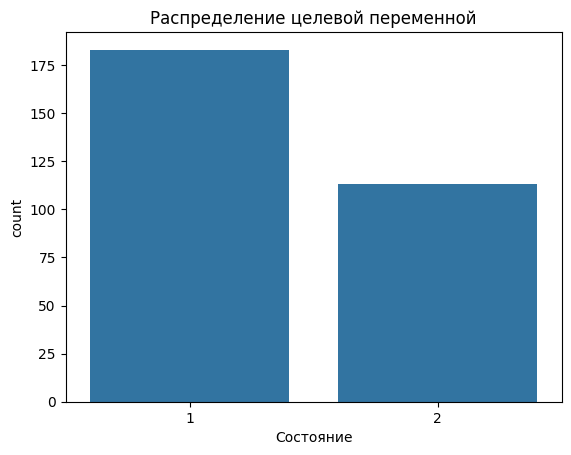

In [49]:
sns.countplot(x='Состояние', data=df)
plt.title('Распределение целевой переменной');

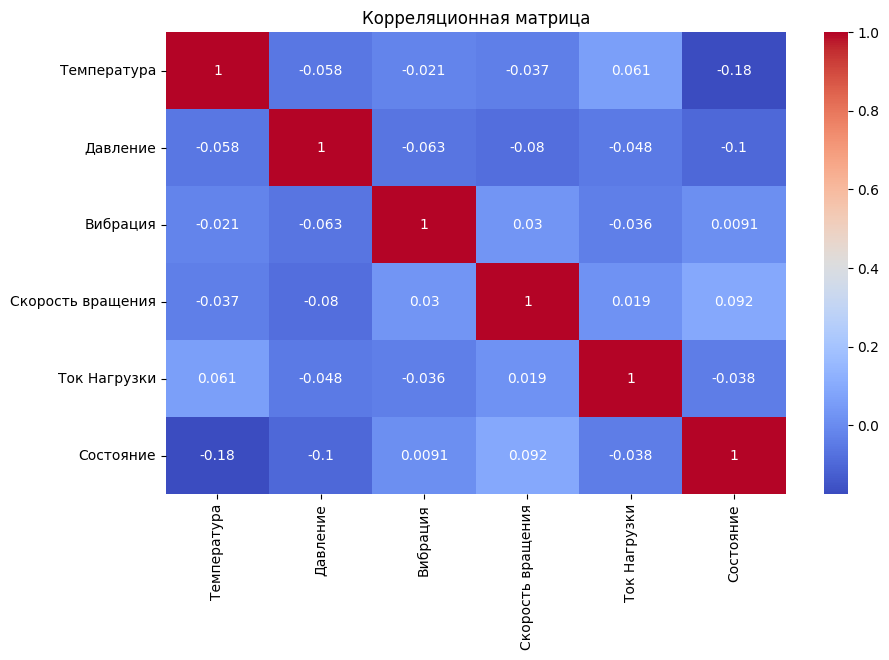

In [50]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[df.columns].corr(), annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица');

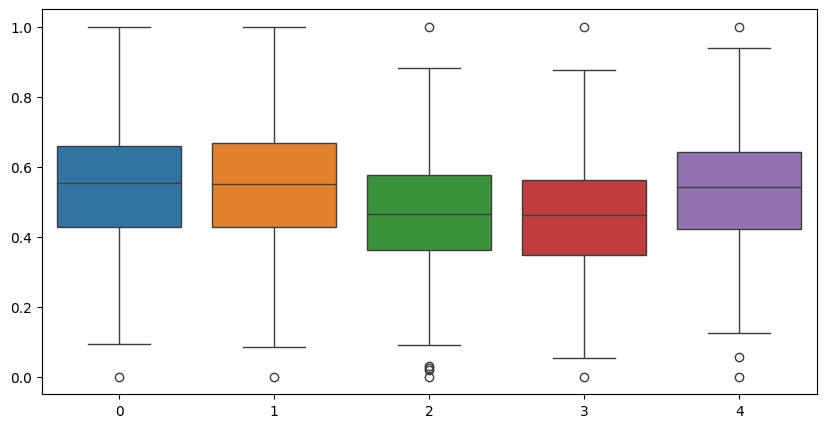

In [51]:
plt.figure(figsize=(10, 5))
scaler = MinMaxScaler()
sns.boxplot(data=scaler.fit_transform(df.drop("Состояние",axis=1))); #много выбросов

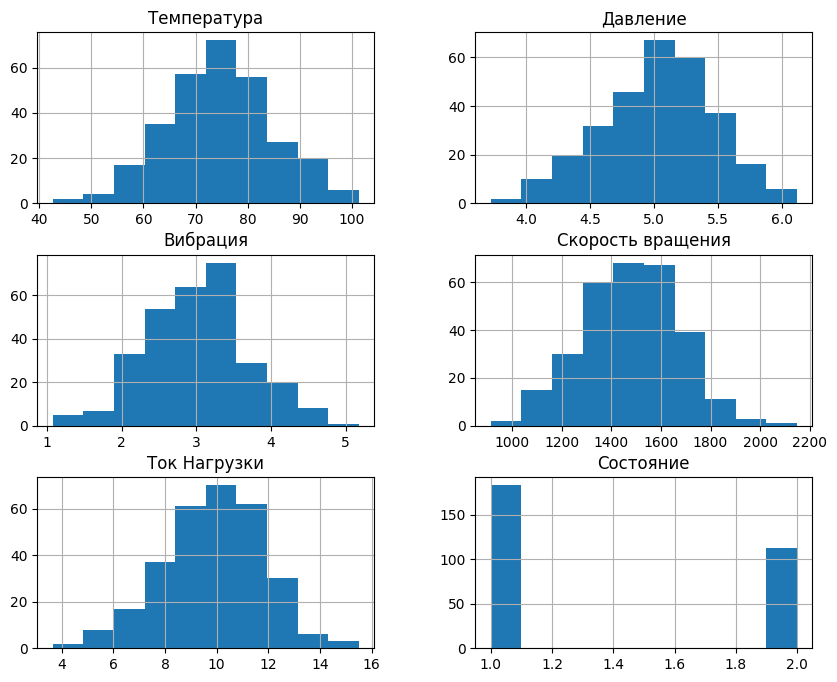

In [52]:
df.hist(figsize=(10,8));

In [53]:
X = df.drop("Состояние", axis=1)
pca = PCA(n_components=5)
X = pd.DataFrame(pca.fit_transform(X))
X["Состояние"] = df["Состояние"]

<Figure size 1000x600 with 0 Axes>

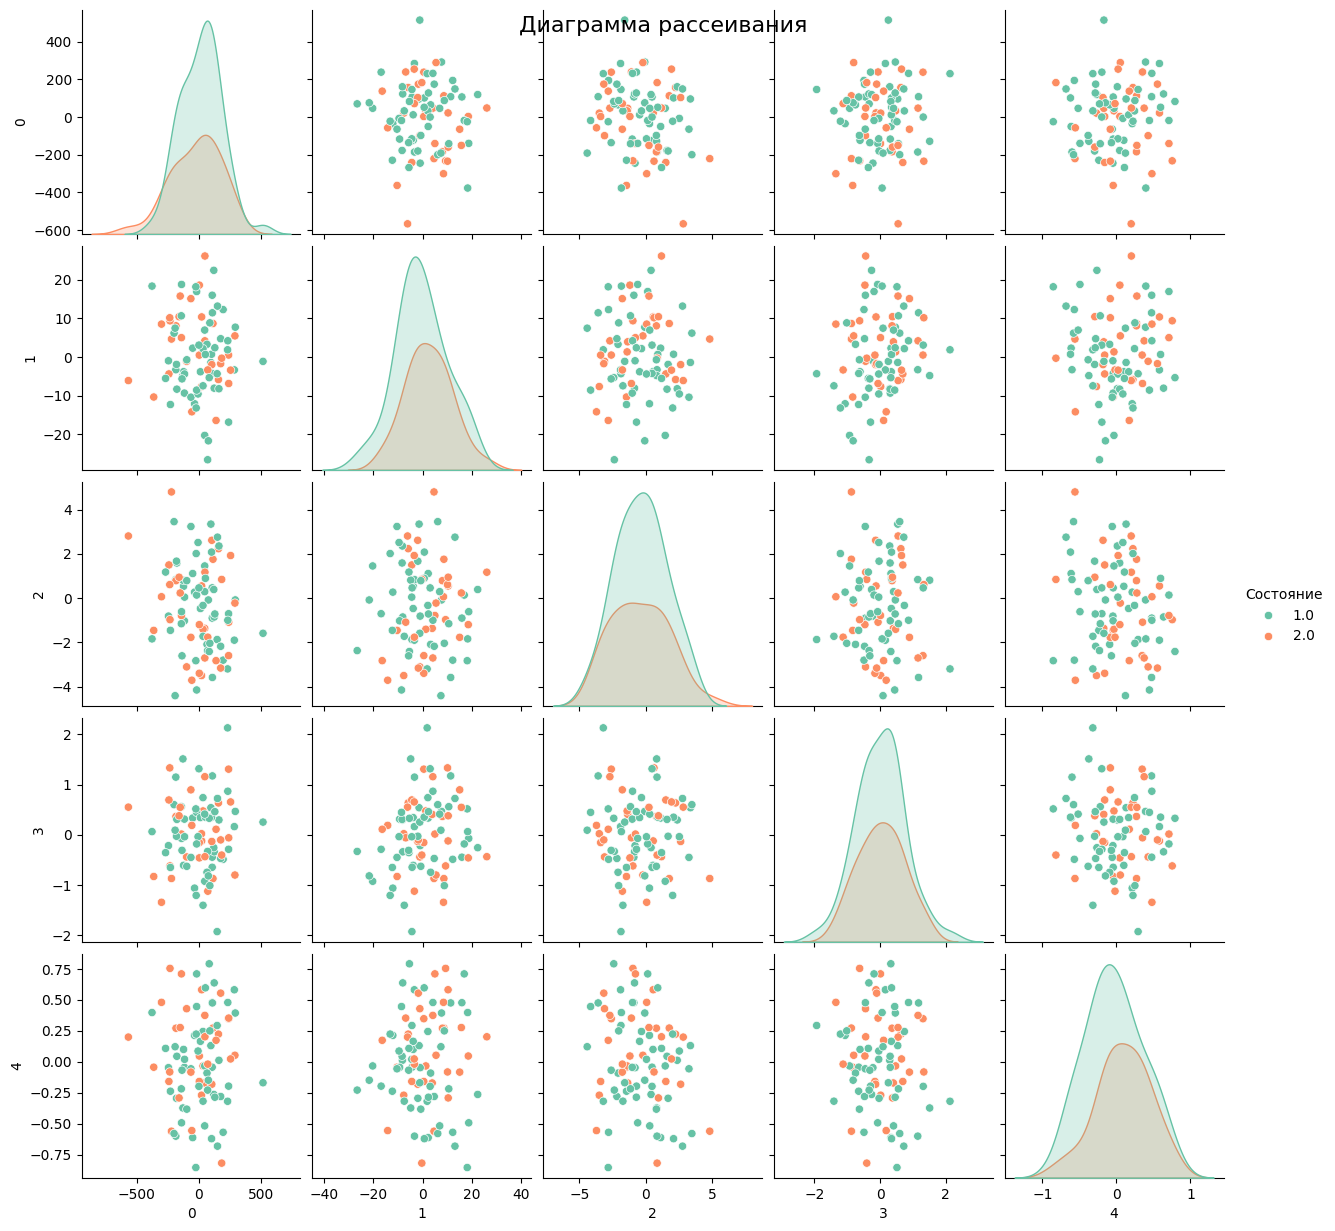

In [54]:
plt.figure(figsize=(10, 6))
sns.pairplot(X, hue="Состояние", palette="Set2")
plt.suptitle('Диаграмма рассеивания', size=16);

## Предобработка

In [55]:
from sklearn.decomposition import PCA

def preprocess_data(df):
    def remove_outliers_iqr(df, column):
        Q1 = df[column].quantile(0.05)
        Q3 = df[column].quantile(0.95)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    
    #выбросы
    for column in ['Температура', 'Давление', 'Вибрация', 'Скорость вращения','Ток Нагрузки']:
       df = remove_outliers_iqr(df, column)

    
    X = df.drop("Состояние", axis=1)
    y = df["Состояние"]

    #scaler = StandardScaler()
    scaler = MinMaxScaler()
    X = scaler.fit_transform(X) # мин-макс получился лучше
    
    # Применение PCA
    #pca = PCA(n_components=3)
    #X = pca.fit_transform(X)
    
    X_train, X_test, y_train, y_test = train_test_split(X, pd.get_dummies(y).values, test_size=0.2, random_state=42)
    
    #smote = SMOTE()
    #X_train, y_train = smote.fit_resample(X_train, y_train)
    
    return X_train, X_test, y_train, y_test

In [56]:
X_train, X_test, y_train, y_test = preprocess_data(df)

In [1]:
from sklearn.utils.class_weight import compute_class_weight

class_labels = np.unique(np.argmax(y_train, axis=1))
class_weights = compute_class_weight('balanced', classes=class_labels, y=np.argmax(y_train, axis=1))
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}

print("Class weights:", class_weights_dict)

NameError: name 'np' is not defined

## Строим модель

In [58]:
model_keras = tf.keras.Sequential([
    keras.layers.Dense(64, activation='leaky_relu', input_shape=(5,)),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(16, activation='leaky_relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(2, activation='softmax')
])

model_keras.compile(optimizer = 'adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy', 'precision', 'recall'])

history = model_keras.fit(X_train, y_train, 
                          epochs=50,
                          class_weight=class_weights_dict, 
                          batch_size=32, 
                          validation_split=0.1)


Epoch 1/50


C:\Dev\Jupyter\dist\pyenv3.12.7-win64\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.4299 - loss: 1.1893 - precision: 0.4299 - recall: 0.4299 - val_accuracy: 0.5000 - val_loss: 0.6974 - val_precision: 0.5000 - val_recall: 0.5000
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5108 - loss: 0.9062 - precision: 0.5108 - recall: 0.5108 - val_accuracy: 0.5417 - val_loss: 0.6949 - val_precision: 0.5417 - val_recall: 0.5417
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5747 - loss: 0.7866 - precision: 0.5747 - recall: 0.5747 - val_accuracy: 0.5417 - val_loss: 0.6936 - val_precision: 0.5417 - val_recall: 0.5417
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4612 - loss: 0.7586 - precision: 0.4612 - recall: 0.4612 - val_accuracy: 0.5000 - val_loss: 0.6905 - val_precision: 0.5000 - val_recall: 0.5000
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5800 - loss: 0.6789 - precision: 0.5800 - recall: 0.5800 - val_accuracy: 0.5417 - val_loss: 0.6903 - val_precision: 0.54

In [36]:
test_loss, test_accuracy, test_prec, test_recall = model_keras.evaluate(X_test, y_test)
print(f'Test accuracy: {test_accuracy}')
print(f'Test loss: {test_loss}')
print(f'Test precision: {test_prec}')
print(f'Test recall: {test_recall}')

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6555 - loss: 0.8859 - precision: 0.6596 - recall: 0.6490 
Test accuracy: 0.65625
Test loss: 0.8901678919792175
Test precision: 0.6595744490623474
Test recall: 0.6458333134651184


## Оценка модели

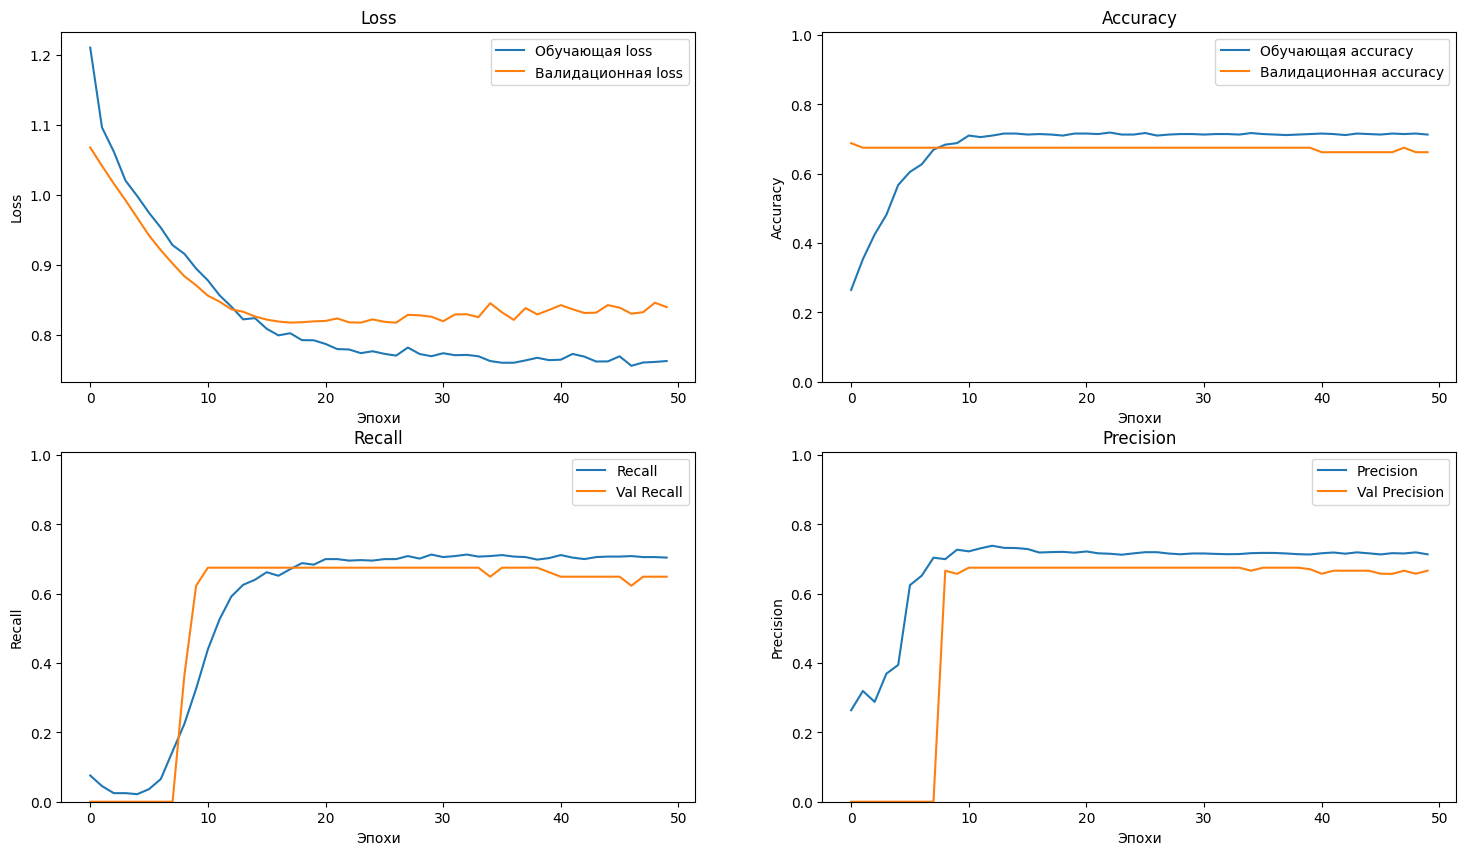

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))

plt.subplot(2, 2, 1) 
plt.plot(history.history['loss'], label='Обучающая loss')
plt.plot(history.history['val_loss'], label='Валидационная loss')
plt.title('Loss')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(history.history['accuracy'], label='Обучающая accuracy')
plt.plot(history.history['val_accuracy'], label='Валидационная accuracy')
plt.title('Accuracy')
plt.xlabel('Эпохи')
plt.ylabel('Accuracy')
plt.legend()

plt.ylim(0,1.01)

plt.subplot(2, 2, 3)
plt.plot(history.history['recall'], label='Recall')
plt.plot(history.history['val_recall'], label='Val Recall')
plt.title('Recall')
plt.xlabel('Эпохи')
plt.ylabel('Recall')
plt.legend()

plt.ylim(0,1.01)

plt.subplot(2, 2, 4)
plt.plot(history.history['precision'], label='Precision')
plt.plot(history.history['val_precision'], label='Val Precision')
plt.title('Precision')
plt.xlabel('Эпохи')
plt.ylabel('Precision')
plt.legend()

plt.ylim(0,1.01)

plt.show()


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


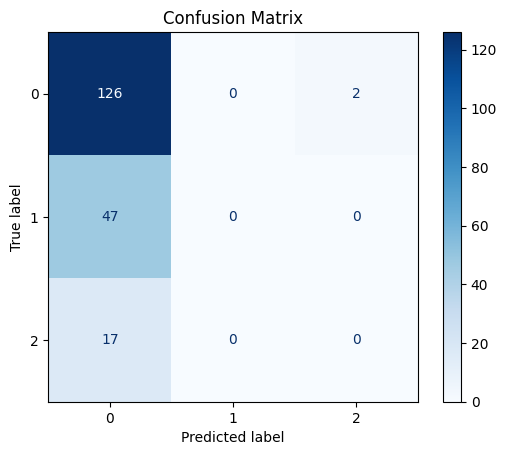

In [38]:
y_score = model_keras.predict(X_test)

y_pred = np.argmax(y_score, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix');